In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import math
import copy


import matplotlib.pyplot as plt
from data_loader import *
from utils import *
from utils_draw import *
from GAN import *
from GAN_separate import *
from combined_data_loader import *
from Optimization_single_node import *
from Optimization_multi_node import *
from tqdm import tqdm

In [2]:
class Args:
    def __init__(self):
        # ----- problem / optnet -----
        self.T = 24
        self.base_mva = 100.0
        self.capacity_scale = 4.5
        self.ramp_rate = 0.5
        self.voll = 200.0
        self.vosp = 50.0
        self.M_beta = 1e4
        self.pwl_segments = 10

        # IMPORTANT: add these to match gurobi
        self.reserve_up_ratio = 0.05
        self.reserve_dn_ratio = 0.02
        self.rt_up_ratio = 3.0
        self.rt_dn_ratio = 0.5

        self.N_scen = 10       # <== OptNet真正求解的场景池 (即 K)
        self.S_full = 100       # VAE 现场吐出的大量候选场景数 (S 池)
        self.K_rand = 0       # K里面有多少条纯随机保留(防过拟合)
        self.tau_gumbel = 1.0     # Gumbel Softmax 温度
        self.eps_uniform = 0.1 # 防震荡平滑参数
        self.lambda_div = 1e5   # [新增] 避免多头选到同一个场景的相互排斥惩罚力度

        # ----- 分段训练控制参数 -----
        self.device = "cuda"
        self.train_batch_size = 8   # (注意: 原来你的叫 dfl_batch_size, 统一改成 batch_size 给 DataLoader 读)
        self.test_batch_size = 8
        self.solver = "ECOS"
        
        self.filter_epochs = 5 # Stage 2 (训Filter) 轮数
        self.filter_lr = 1e-3   # Stage 2 学习率
        self.dfl_epochs = 1     # Stage 3 (联合微调) 轮数 (端到端微调极耗时，一般1-3轮即收敛)
        self.dfl_lr = 1e-6      # Stage 3 学习率 (必须极小，防崩坏)
        
args = Args()

In [ ]:

set_seed(42)
data_path = "../Data/load_data_city_4_2.csv"
eps_search=pd.read_csv('../Result/eps_search.csv')
eps=int(eps_search[eps_search['model']=='gan_s']['eps'])
target_nodes = [f"4-2-{i}" for i in range(11)]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data=pd.read_csv(data_path)
data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
data_2022 = data[data["DATETIME"].dt.year == 2022].copy()
Lmin, Lmax = system_hourly_load_minmax(data_2022, datetime_col="DATETIME",node_cols=target_nodes)
Lmax_total=Lmax.sum(0)# (24,)
Lmin_total=Lmin.sum(0) # (24,)
args.Lmax_total=Lmax_total
args.Lmin_total=Lmin_total
args.eps_value=eps

In [ ]:
set_seed(42)
data_path = "load_data_city_4_2.csv"
target_nodes = [f"4-2-{i}" for i in range(11)]
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

models_s, handlers_s, pack_data_s = run_gan_separate(
    data_path=data_path,
    node_cols=target_nodes,
    DataHandler=Dataset_load_single_node_parametric,
    device=device,
    epochs=1000,
    batch_size=128,
    lr_g=1e-4,
    lr_d=4e-4,
    patience=50,
    verbose=True,
    train_length=8760,
    val_ratio=0.2,
    seed=42,

    z_dim=128,
    hidden=512,
    dropout=0.0,
    n_critic=1,
    grad_clip=1.0,
    lambda_adv=1.0,

    lambda_sup=10,
    sup_warmup_epochs=50,
    sup_loss_type="l1",
    sup_samples=16,   

    select_z_temp=True,
    ztemps=np.linspace(0.5, 4, 8),
    ztemp_n_samples=50,
    ztemp_batch_size=128,
    ztemp_quantiles=[0.05 * i for i in range(1, 20)],
)


In [7]:

set_seed(0)
window_pack_s_gan_train = sample_window_gan_separate(
    models_s, handlers_s, pack_data_s,
    target_nodes=target_nodes,
    horizon_days=292, start_day=0, n_samples=200, seq_len=24,
    z_temp=None, split="train",
)

set_seed(0)
window_pack_s_gan_val = sample_window_gan_separate(
    models_s, handlers_s, pack_data_s,
    target_nodes=target_nodes,
    horizon_days=73, start_day=0, n_samples=200, seq_len=24,
    z_temp=None, split="val",
)

set_seed(0)
window_pack_s_gan_test = sample_window_gan_separate(
    models_s, handlers_s, pack_data_s,
    target_nodes=target_nodes,
    horizon_days=303, start_day=0, n_samples=200, seq_len=24,
    z_temp=None, split="test",
)


      node     L         mse       rmse  pinball_avg
0    4-2-0  7272   44.685905   6.684752     1.902762
1    4-2-1  7272  125.542511  11.204575     3.179445
2    4-2-2  7272   68.354164   8.267658     2.350849
3    4-2-3  7272  116.038666  10.772124     3.144620
4    4-2-4  7272   56.039192   7.485933     2.178338
5    4-2-5  7272   62.244282   7.889505     2.306569
6    4-2-6  7272   54.973347   7.414401     2.148906
7    4-2-7  7272   61.577557   7.847137     2.165708
8    4-2-8  7272   77.515884   8.804311     2.600219
9    4-2-9  7272   61.748775   7.858039     2.212815
10  4-2-10  7272   14.743812   3.839767     1.112159


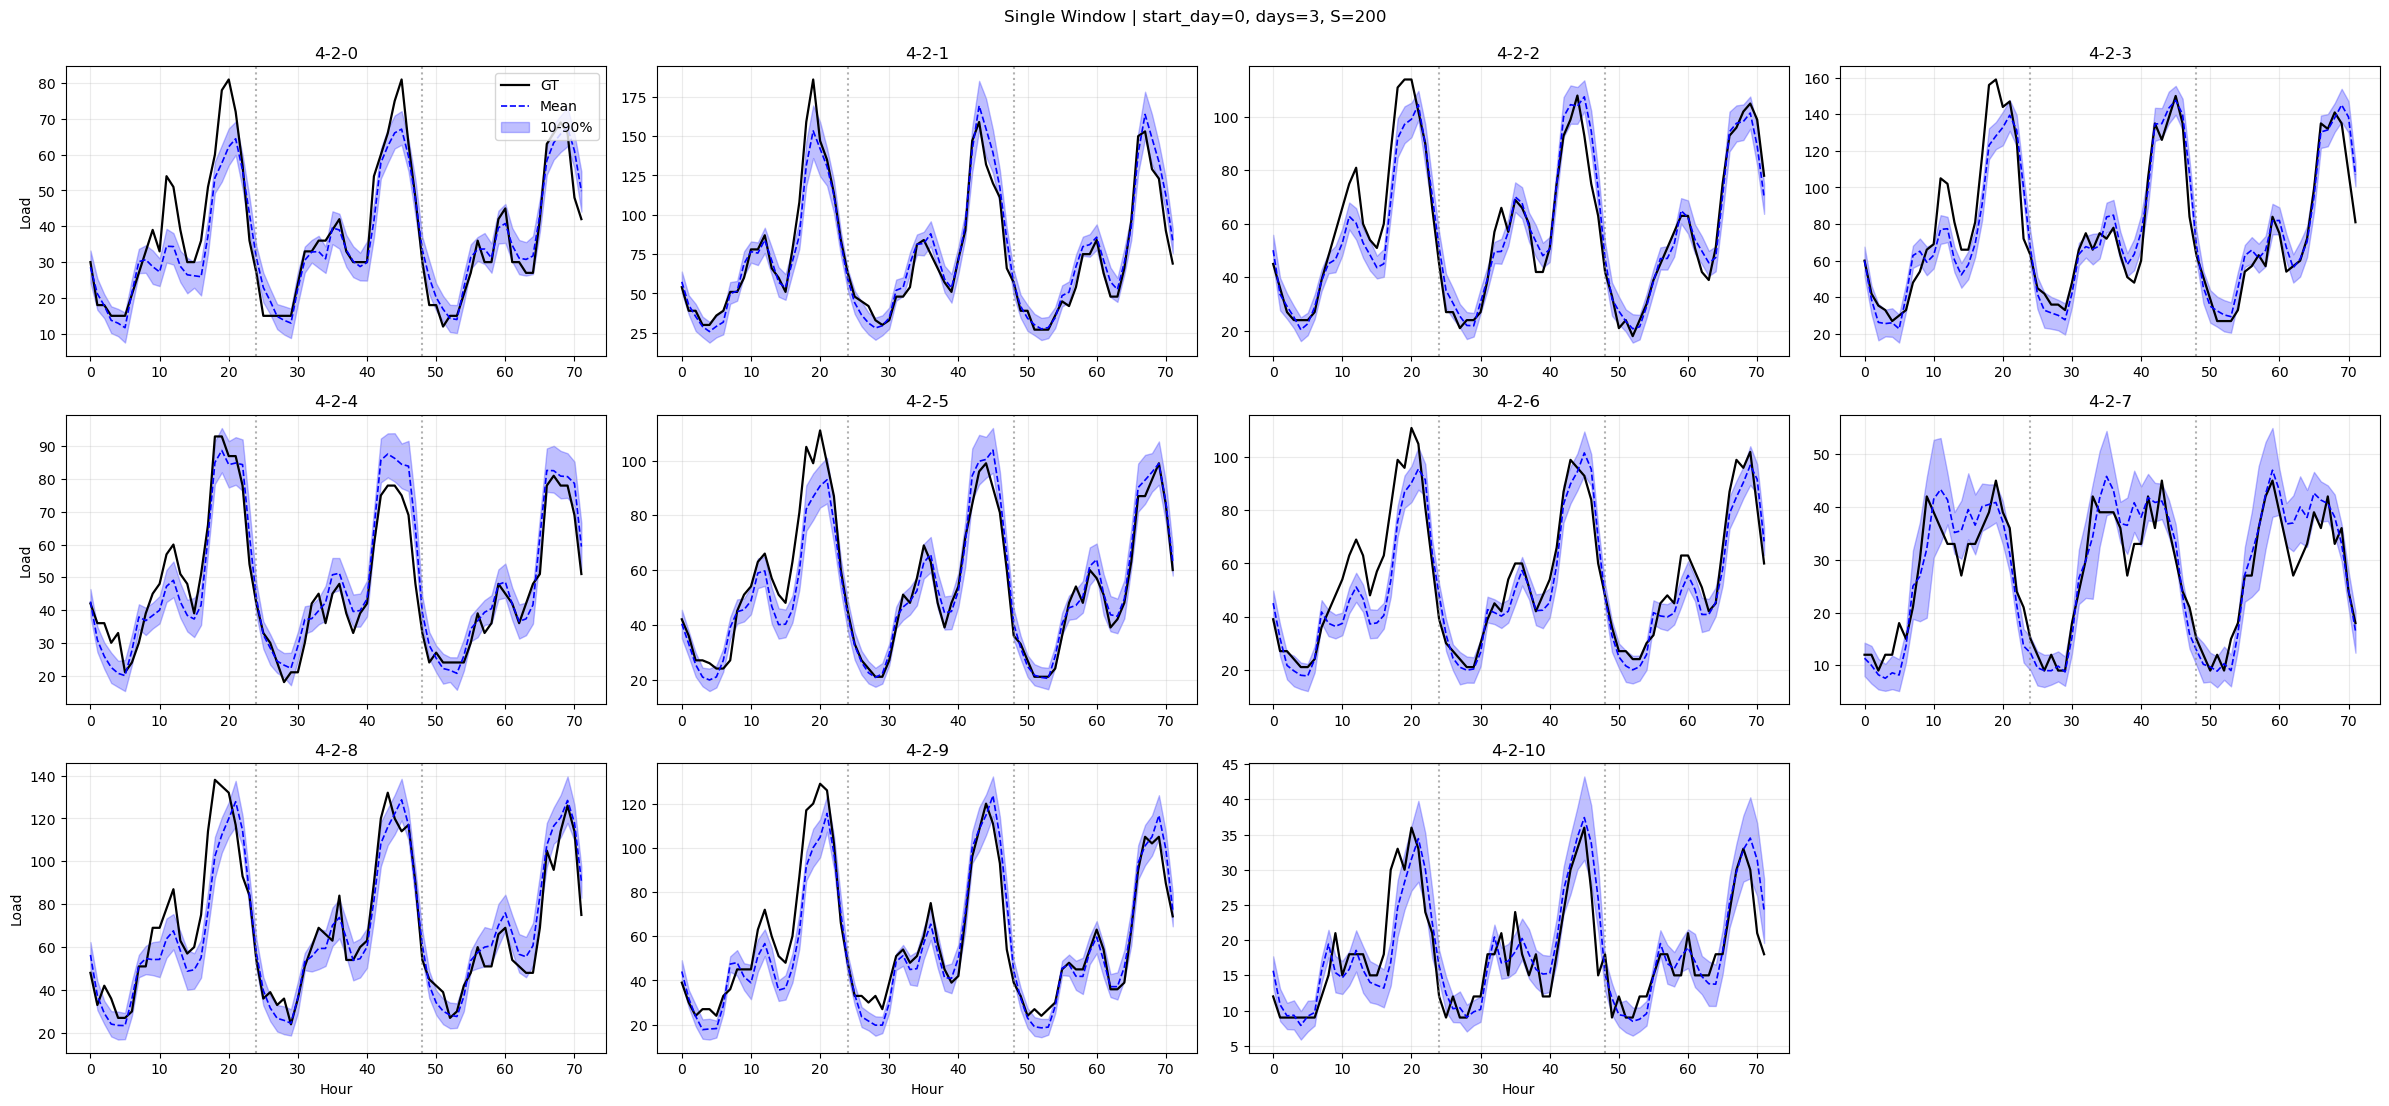

In [9]:

window_pack_draw  = sample_window_gan_separate(
    models_s, handlers_s, pack_data_s,
    target_nodes=target_nodes,
    horizon_days=3, start_day=0, n_samples=200, seq_len=24,
    z_temp=None, split="test",
)

dfm = compute_metrics_window(window_pack_s_gan_test)
print(dfm)
plot_window_curve(window_pack_draw, print_metrics=False)

In [13]:
import pickle

with open('../Result/GAN/models_s.pkl', 'wb') as f:
    pickle.dump(models_s, f)
with open('../Result/GAN/handlers_s.pkl', 'wb') as f:
    pickle.dump(handlers_s, f)
with open('../Result/GAN/pack_data_s.pkl', 'wb') as f:
    pickle.dump(pack_data_s, f)

with open('../Result/GAN/window_pack_s_gan_test.pkl','wb') as f:
    pickle.dump(window_pack_s_gan_test, f)

with open('../Result/GAN/window_pack_s_gan_train.pkl','wb') as f:
    pickle.dump(window_pack_s_gan_train, f)

with open('../Result/GAN/window_pack_s_gan_val.pkl','wb') as f:
    pickle.dump(window_pack_s_gan_val, f)